##  THIS NOTEBOOK IS FOR PYTORCH BEGINNERS 

### IMPORT LIBRARIES

In [1]:
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

### CREATE DATASET

In [12]:
train_data = pd.read_csv('../input/digit-recognizer/train.csv')
test_data = pd.read_csv('../input/digit-recognizer/test.csv')

y = train_data.label
X = train_data.drop(['label'], axis=1)

X = X/255.0
test_data = test_data/255.0

x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print('shape of x_train ', x_train.shape)
print('shape of x_val ', x_val.shape)
print('shape of y_val ', y_val.shape)
print('shape of y_train ', y_train.shape)


class Digits(torch.utils.data.Dataset):
    def __init__(self, pixel, label):
        self.x = pixel
        self.y = label.values
        
    def __len__(self):
        return len(self.x)
        
    def __getitem__(self, index):
        x = self.x.values[index]
        y = self.y[index]
        return x, y
    
train_ds = Digits(x_train, y_train)
val_ds = Digits(x_val, y_val)
test_ds = Digits(test_data, pd.Series(np.zeros(784)))

# dataloader
batch_size = 64
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=batch_size)

shape of x_train  (33600, 784)
shape of x_val  (8400, 784)
shape of y_val  (8400,)
shape of y_train  (33600,)


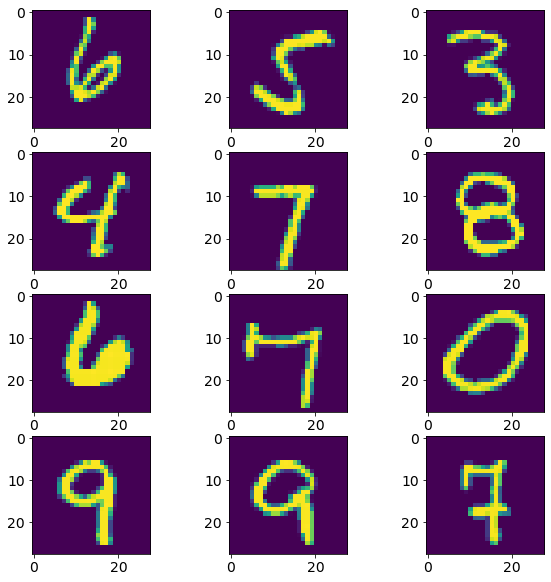

In [20]:
plt.figure(figsize=(10,10))
for i in range(12):
    plt.subplot(4, 3, i+1)
    plt.imshow(train_ds[i][0].reshape(28, 28))
plt.show()

### VISUALIZE THE DATA IN 2D PLOT

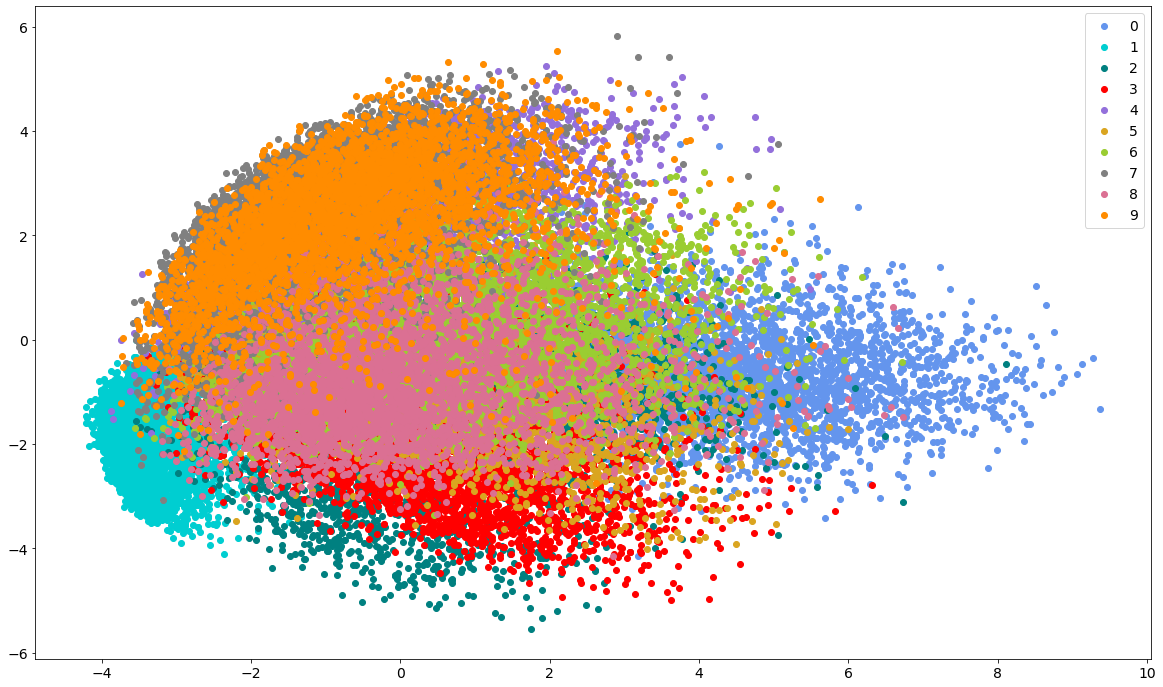

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components= 2)
data_reduced = pca.fit_transform(X)

labels = np.unique(y)
colors = ['cornflowerblue','darkturquoise','teal','red','mediumpurple','goldenrod','yellowgreen','grey','palevioletred','darkorange']
plt.figure(figsize=(20,12))
plt.rc('font', size=14)
for label in labels:
    subset = data_reduced[train_data.label==label]
    pca_1 = [row[0] for row in subset]
    pca_2 = [row[1] for row in subset]
    plt.scatter(pca_1,pca_2, c=colors[label], label= labels[label])
    

plt.legend()
plt.show()

### TRAIN THE MODEL

In [18]:
class my_model(torch.nn.Module):
    def __init__(self):
        super(my_model, self).__init__()
        self.layer = torch.nn.Linear(784, 500)
        self.output_layer = torch.nn.Linear(500, 10)
        
    def forward(self, x):
        y = self.layer(x)
        y = torch.nn.functional.relu(y)
        y = self.output_layer(y)
        y = torch.nn.functional.softmax(y, dim=1)
        return y

def train_model(model, optimizer, train_dl, val_dl, epochs):
    for i in range(epochs):
        total = 0
        sum_loss = 0
        for x, y in train_dl:
            batch = y.shape[0]
            x = x.cuda().float()
            y = y.cuda()
            # forward pass 
            predict_class = model(x)
            # calculate loss
            loss = torch.nn.functional.cross_entropy(predict_class, y)

            # initialise the gradients
            optimizer.zero_grad()
            # backpropagate
            loss.backward()
            # update weights
            optimizer.step()

            total += batch
            sum_loss += loss.item()

        train_loss = sum_loss / total
        val_loss, val_acc = val_model(model, val_dl)

        print("epoch {} train_loss {:.3f} val_loss {:.3f} val_acc {:.3f}".format(i, train_loss, val_loss, val_acc))
        
    return sum_loss/total

def val_model(model, val_dl):
    sum_loss = 0
    total =0
    correct = 0
    
    for x, y in val_dl:
        batch = y.shape[0]
        x = x.cuda().float()
        y = y.cuda()
        y_pred = model(x)
        loss = torch.nn.functional.cross_entropy(y_pred, y)
        _, index = torch.max(y_pred, 1)
        correct += index.eq(y).sum().item()
        total += batch
        sum_loss += loss.item()
        val_loss = sum_loss/total
        val_acc = correct/total
        
    return val_loss, val_acc


model = my_model().cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model(model, optimizer, train_dl, val_dl, 50)

epoch 0 train_loss 0.025 val_loss 0.024 val_acc 0.923
epoch 1 train_loss 0.024 val_loss 0.024 val_acc 0.947
epoch 2 train_loss 0.024 val_loss 0.024 val_acc 0.955
epoch 3 train_loss 0.023 val_loss 0.024 val_acc 0.952
epoch 4 train_loss 0.023 val_loss 0.024 val_acc 0.964
epoch 5 train_loss 0.023 val_loss 0.024 val_acc 0.967
epoch 6 train_loss 0.023 val_loss 0.024 val_acc 0.968
epoch 7 train_loss 0.023 val_loss 0.024 val_acc 0.966
epoch 8 train_loss 0.023 val_loss 0.023 val_acc 0.971
epoch 9 train_loss 0.023 val_loss 0.023 val_acc 0.969
epoch 10 train_loss 0.023 val_loss 0.023 val_acc 0.972
epoch 11 train_loss 0.023 val_loss 0.023 val_acc 0.972
epoch 12 train_loss 0.023 val_loss 0.023 val_acc 0.971
epoch 13 train_loss 0.023 val_loss 0.023 val_acc 0.973
epoch 14 train_loss 0.023 val_loss 0.023 val_acc 0.972
epoch 15 train_loss 0.023 val_loss 0.023 val_acc 0.970
epoch 16 train_loss 0.023 val_loss 0.023 val_acc 0.973
epoch 17 train_loss 0.023 val_loss 0.023 val_acc 0.971
epoch 18 train_loss 

0.02292412857924189

### EVALUATE THE MODEL

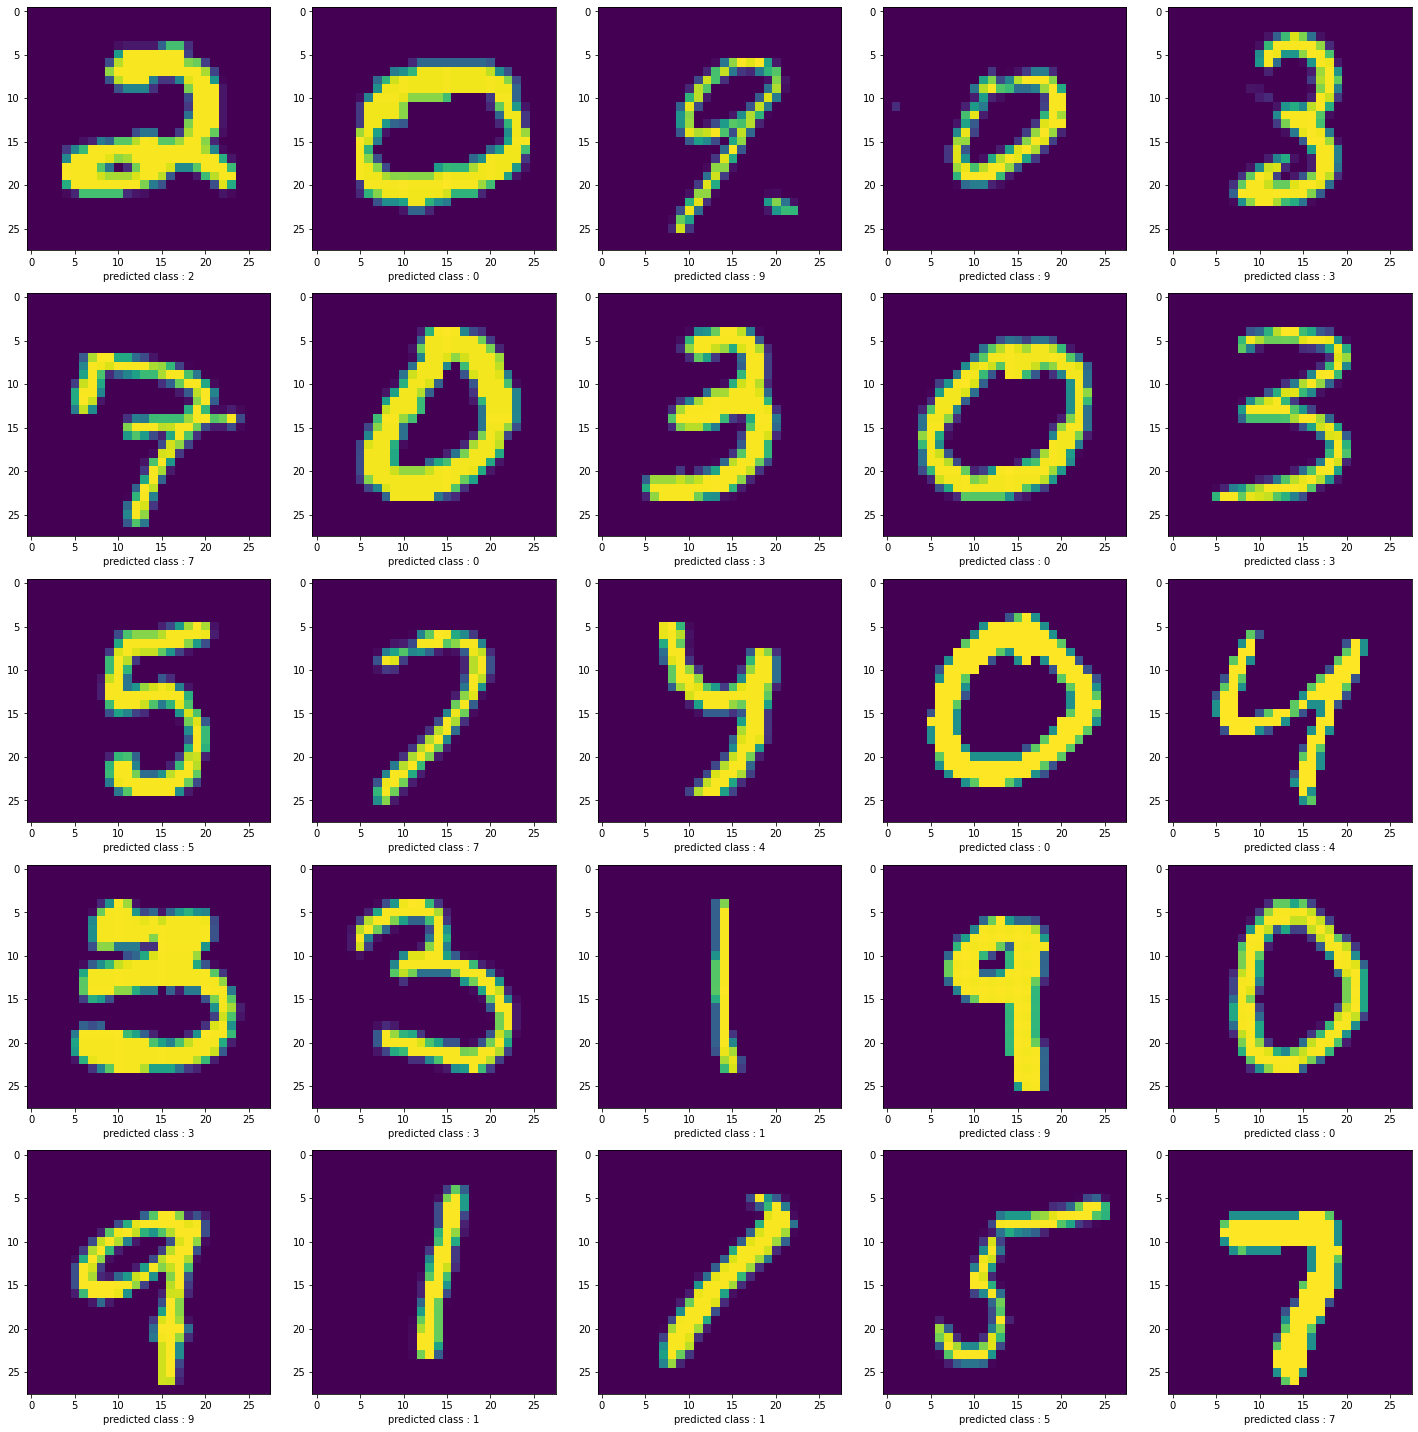

In [7]:
rows, cols = 5, 5

plt.figure(figsize=(20,20))

for i in range(rows*cols):   
    test_x, _ = test_ds[i]
    test_x = torch.FloatTensor(test_x.reshape(-1, 784))
    y_class = model(test_x.cuda())
    y = y_class.cpu().data.numpy().argmax()
    confidence = y_class.cpu().data.numpy()[0][y]
    plt.subplot(rows, cols, i+1)
    plt.imshow(test_ds[i][0].reshape(28, 28))
    plt.xlabel('predicted class : {}'.format(y))
    
plt.tight_layout()
plt.show()